# **Performance on real COVID-19 counts**

This notebook explain how to reproduce the Figure n.6 of the article to compare the performance of our proposed estimator ```Un-CP``` to litterature estimators on real COVID-19 counts (more precisely, the maximum likelihood estimator and [APURE](https://github.com/bpascal-fr/APURE-Estim-Epi) estimator, see [this article](https://hal.science/hal-04705913v1/file/APURE_hal.pdf) for more information).

*Author: Benjamin Pineau, Barbara Pascal, Sébastien Bourguignon*

### **Important remark**:

This notebook requires a GitHub repository. Please install [EpiJointSpatiotempEstim](https://github.com/elasalle/EpiJointSpatiotempEstim/) before using this notebook. 

Write the path to this toolbox on your device below.

In [9]:
import sys 
from pathlib import Path

# path to the EpiJointSpatiotempEstim repository on your device
# ======================================================================================================== #
path_EpiJointSpatiotempEstim = "/Users/benji/Documents/Centrale_Nantes/EI3/OPDOC/EpiJointSpatiotempEstim/" #
# ======================================================================================================== #

prog_python_path = Path(path_EpiJointSpatiotempEstim).resolve()

if str(prog_python_path) not in sys.path:
    sys.path.insert(0, str(prog_python_path))

In [10]:
%run ../utils/preamble.py

Select a country between *Morocco*, *Brazil*, *Croatia* and *Luxembourg*. 

In [11]:
country = "Croatia"

df = pd.read_csv(f'../data/datasets/test.csv')
row = df[df["Country"] == country].iloc[0] 
fDay = row["firstDay"]
lDay = row["lastDay"]

Z, options = get_real_counts(country, fDay, lDay, 'JHU', '../')
alpha = 0.1
Z_alpha_test = sliding_median_numpy(Z, alpha)
dates = options['dates']
Phi_test = crafting_phi.buildPhi()

tmpDates, Z, PhiZ = crafting_phi.buildZPhi(dates, Z, Phi_test)
_, Z_alpha, PhiZ_alpha = crafting_phi.buildZPhi(dates, Z_alpha_test, Phi_test)

formattedDates = [mdates.datestr2num(t) for t in tmpDates]

Opening data from Johns Hopkins University.


## **Reproduction numbers estimator**

### **ML estimator**
The maximum likelihood estimator of the reproduction number is defined as
$$
\widehat{\mathsf{R}}_t^{\mathsf{MLE}} = \frac{\mathsf{Z}_t}{\Phi_t},
$$

In [12]:
Rt_MLE = Z[:]/PhiZ[:]

### **EpiEstim estimator**

A more robust smoothed estimator defined in [this article](https://academic.oup.com/aje/article/178/9/1505/89262)

$$
\widehat{\mathsf{R}}_{t,\tau}^{\mathsf{EpiEstim}} = \frac{\sum_{v = t-\tau + 1}^t \mathsf{Z}_v + a}{\sum_{v = t-\tau + 1}^t \Phi_v + 1/b}
$$

In [13]:
# Smoothing window lenght
tau = 7
# Analytic computation
Rt_Gamma, options_Gamma = Rt_Gamma(Z_alpha, tau=tau, options=options)

### **APURE estimator**

To improve robustness to the low quality of real data, variational estimators with data-driven selection of optimal parameter have also been introduced in [this article](https://hal.science/hal-04705913v1/file/APURE_hal.pdf). 

**WARNING**: The APURE estimators where computed thanks to the toolbox [APURE-Estim-Epi](https://github.com/bpascal-fr/APURE-Estim-Epi). As they can be relleay slow to compute (several hours), we provide a copy of the estimators obtained after calculations. 

In [14]:
R_APURE = loadmat(f'../data/APURE_estimates/R_APURE_{country}.mat', squeeze_me = True)['R_APURE_P_med']

### **UnCP estimator**

We finally compute our proposed estimator obtained with an unfolded primal-dual algorithm.

In [15]:
Z_alpha = torch.tensor(Z_alpha[:], dtype=torch.float).unsqueeze(0)
PhiZ_alpha = torch.tensor(PhiZ_alpha[:], dtype=torch.float).unsqueeze(0)
std_Z = Z_alpha.std(dim = None, keepdims = True, unbiased=False)
Z_std = Z_alpha/std_Z
PhiZ_std = PhiZ_alpha/std_Z
R_ones = torch.ones_like(Z_alpha)

model_UnCP = nn_conv('cpu', 10, learning_rate=1e-4, nb_filter=20)
load_model(model_UnCP, '../data/models/varlevelAll_K10_J20.pth')

Rt_UnCP = model_UnCP.forward(R_ones.unsqueeze(0), Z_std.unsqueeze(0), PhiZ_std.unsqueeze(0))

/Users/benji/Documents/Centrale_Nantes/Covid-R-unroll-v2/utils/database_gradient_descent.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  param_model = torch.load(init_p

## **Comparison of estimators**

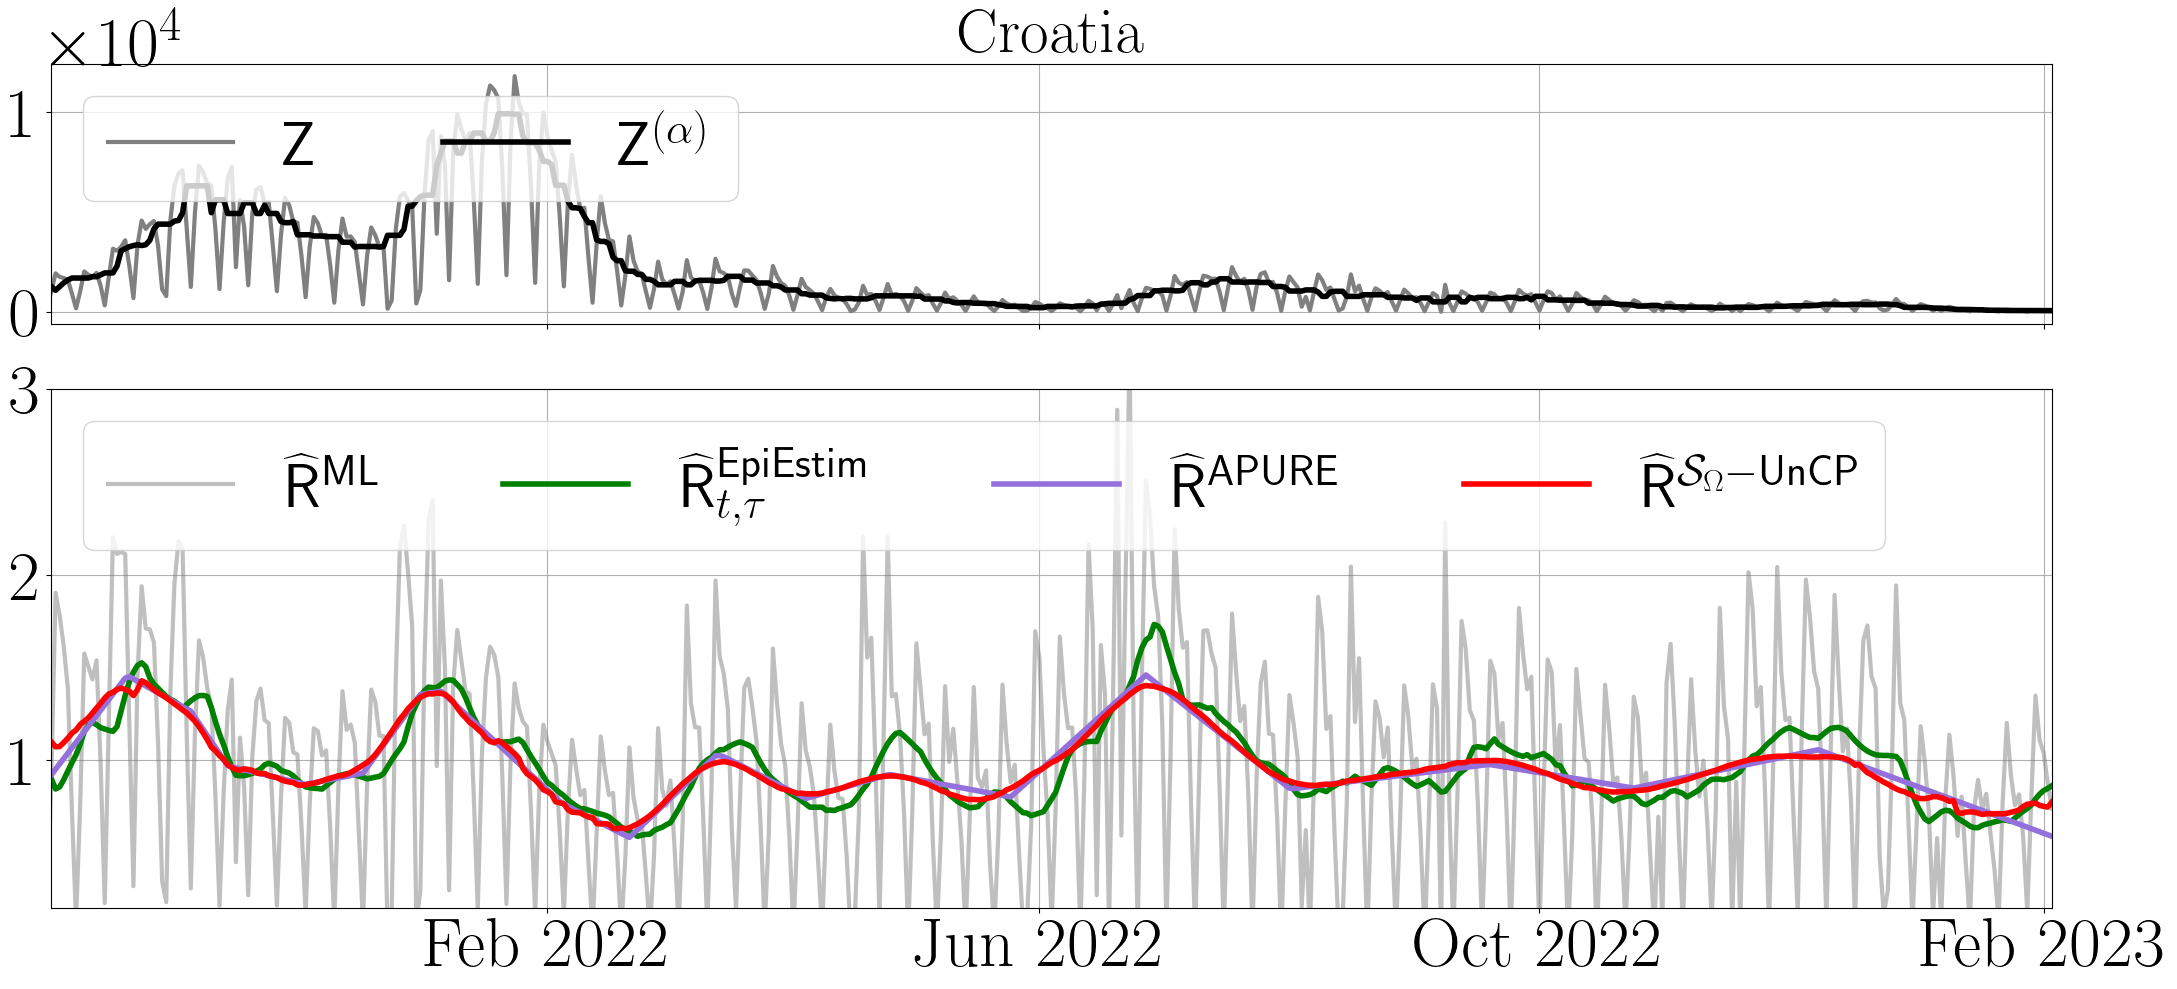

In [16]:
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-2, 2))

fig = plt.figure(figsize=(22, 10))
gs = GridSpec(2, 1, height_ratios=[2, 4])
ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1], sharex=ax0)

axes = [ax0, ax1]
# =====================
# Daily count
axes[0].plot(formattedDates[:], Z, label = r'$\mathsf{Z}$', color = 'grey', linewidth=3)
# =====================
# Pre-processed counts with median filtering
axes[0].plot(formattedDates[:], Z_alpha[0], label = r'$\mathsf{Z}^{(\alpha)}$', color = 'black')

axes[0].tick_params(labelbottom=False)
axes[0].tick_params(axis='both', which='major', labelsize=50)
axes[0].yaxis.set_major_formatter(formatter)
axes[0].grid()

# =====================
# ML estimator
axes[1].plot(formattedDates[:], Rt_MLE, alpha = 0.5, color = 'grey', label = r'$\widehat{\mathsf{R}}^{\mathsf{ML}}$', linewidth=3)

# =====================
# EpiEstim estimator
axes[1].plot(formattedDates[1:], Rt_Gamma, label = r'$\widehat{\mathsf{R}}_{t,\tau}^{\mathrm{\tiny\mathsf{EpiEstim}}}$', color = color_green_cori)

# =====================
# APURE estimator
axes[1].plot(formattedDates[1:], R_APURE, label = r'$\widehat{\mathsf{R}}^{\mathrm{\tiny\mathsf{APURE}}}$', color = 'mediumpurple')

# =====================
# UnCP estimator
axes[1].plot(formattedDates[:], Rt_UnCP.detach().numpy()[0][0], label = r'$\widehat{\mathsf{R}}^{\mathcal{S}_{\Omega}-\mathsf{UnCP}}$', color = 'red')

axes[1].set_ylabel("", fontsize=45)
axes[1].set_ylim([0.2, 3])
axes[1].grid()
axes[1].set_xlim(formattedDates[2], formattedDates[-1])
locator, dateFormatter = display_data.adaptiveDaysLocator(formattedDates)
axes[1].xaxis.set_major_locator(locator)
axes[1].xaxis.set_major_formatter(dateFormatter)
axes[1].tick_params(axis='both', which='major', labelsize=50)


axes[1].legend(ncol = 4, fontsize = 45, loc = 'upper left')
axes[0].legend(ncol = 2, fontsize = 45, loc = 'upper left')

axes[0].set_title(country, fontsize = 45)
plt.tight_layout()
plt.show()